In [ ]:
# IMPORTS
import os
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score
)

In [ ]:

#  PATH SETUP
BASE_DIR = os.getcwd()  # current notebook folder (src)

MODEL_DIR   = os.path.join(BASE_DIR, "models")
FIGURES_DIR = os.path.join(BASE_DIR, "figures")

os.makedirs(FIGURES_DIR, exist_ok=True)

MODEL_PATH = os.path.join(MODEL_DIR, "best_model.pkl")

print("Working directory:", BASE_DIR)
print("Model path:", MODEL_PATH)

Working directory: c:\fraud-detection\src
Model path: c:\fraud-detection\src\models\best_model.pkl


In [ ]:
#  LOAD TEST DATA

print("📂 Loading test data...")

X_test = pd.read_csv("X_test.csv")
y_test = pd.read_csv("y_test.csv").values.ravel()

print("✅ Test data loaded")
print("Test shape:", X_test.shape)

📂 Loading test data...
✅ Test data loaded
Test shape: (56962, 30)


In [ ]:
# LOAD TRAINED MODEL

model = joblib.load(MODEL_PATH)

print("✅ Loaded model:", type(model).__name__)

✅ Loaded model: XGBClassifier


In [ ]:
# MODEL EVALUATION
threshold = 0.5

probs = model.predict_proba(X_test)[:, 1]
preds = (probs >= threshold).astype(int)

roc  = roc_auc_score(y_test, probs)
pr   = average_precision_score(y_test, probs)
prec = precision_score(y_test, preds, zero_division=0)
rec  = recall_score(y_test, preds, zero_division=0)
f1   = f1_score(y_test, preds, zero_division=0)

cm = confusion_matrix(y_test, preds)

print("\n=== Final Model Performance ===")
print(f"ROC-AUC        : {roc:.5f}")
print(f"PR-AUC         : {pr:.5f}")
print(f"Precision      : {prec:.5f}")
print(f"Recall         : {rec:.5f}")
print(f"F1-Score       : {f1:.5f}")
print(f"Fraud Detected : {rec*100:.2f}%")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}")


=== Final Model Performance ===
ROC-AUC        : 0.96824
PR-AUC         : 0.88000
Precision      : 0.88172
Recall         : 0.83673
F1-Score       : 0.85864
Fraud Detected : 83.67%
False Positives: 11
False Negatives: 16


In [ ]:
#  COST-SENSITIVE VIEW

cost_fn = 100  # missed fraud cost
cost_fp = 1    # false alarm cost

total_cost = cm[1,0] * cost_fn + cm[0,1] * cost_fp

print(f"\nEstimated Cost (FN=100×FP): {total_cost:,}")


Estimated Cost (FN=100×FP): 1,611


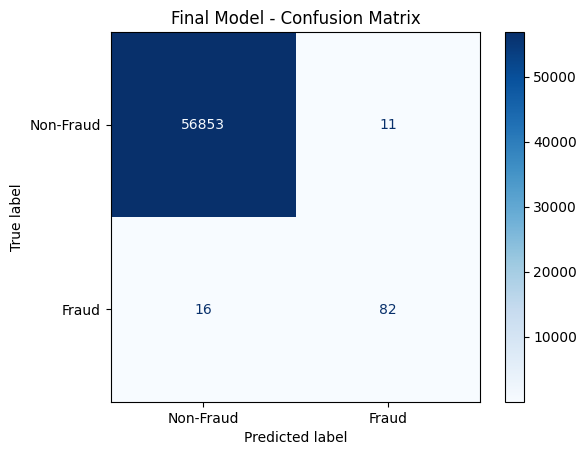

In [ ]:
#  CONFUSION MATRIX


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Fraud", "Fraud"]
)

disp.plot(cmap="Blues")
plt.title("Final Model - Confusion Matrix")
plt.savefig(os.path.join(FIGURES_DIR, "final_cm.png"))
plt.show()

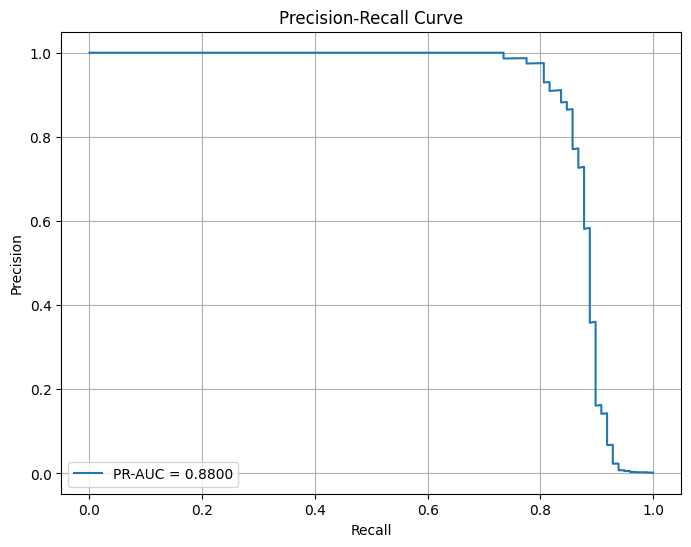

In [ ]:
# PRECISION-RECALL CURVE

precision, recall, _ = precision_recall_curve(y_test, probs)

plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f"PR-AUC = {pr:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(FIGURES_DIR, "final_pr_curve.png"))
plt.show()

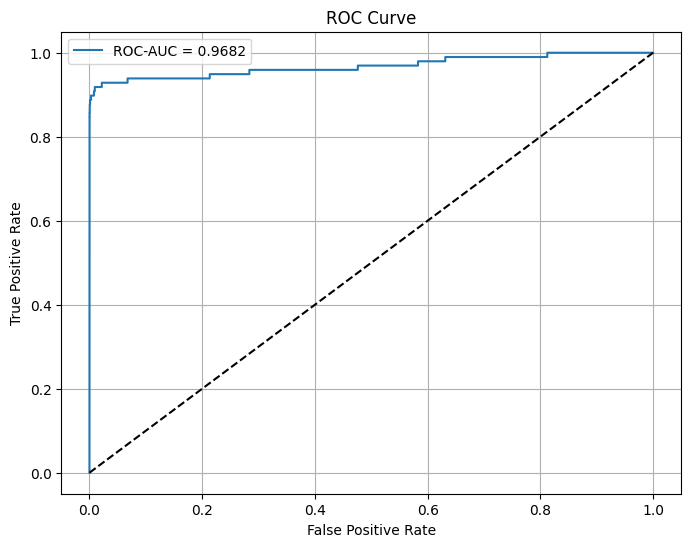


✅ All plots saved in: c:\fraud-detection\src\figures


In [ ]:
# ROC CURVE

fpr, tpr, _ = roc_curve(y_test, probs)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc:.4f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(FIGURES_DIR, "final_roc_curve.png"))
plt.show()

print("\n✅ All plots saved in:", FIGURES_DIR)